# 🐣 Wielkanocne ćwiczenie z matplotlib.patches

Dzisiaj rysujemy kształty geometryczne — ale nie wykresy, tylko obrazek.  
Nasz cel: zbudować królika i jajko wielkanocne z podstawowych kształtów.

**Nowe elementy:**
- `matplotlib.patches` — koła, elipsy, prostokąty, wielokąty, łuki
- `ax.add_patch()` — dodawanie kształtu do wykresu
- `matplotlib.transforms` — obracanie kształtów
- Współrzędne jako narzędzie projektowe


---
## 0. Import

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Gotowe!")


Gotowe!


---
## 1. Czym jest patch?

W matplotlib **patch** to kształt 2D z wypełnieniem i obrysem.  
Każdy patch tworzymy jako obiekt, a potem dodajemy do osi przez `ax.add_patch()`.

Trzy najważniejsze:

| Klasa | Parametry | Opis |
|---|---|---|
| `Circle(xy, radius)` | środek + promień | koło |
| `Ellipse(xy, width, height, angle)` | środek + szerokość + wysokość + kąt | elipsa |
| `Rectangle(xy, width, height)` | lewy-dolny róg + wymiary | prostokąt |
| `Polygon([(x,y), ...])` | lista wierzchołków | dowolny wielokąt |
| `Arc(xy, width, height, angle, theta1, theta2)` | jak elipsa + kąt startowy i końcowy | łuk (tylko obrys) |
| `FancyArrowPatch` | punkt startowy i końcowy | strzałka ze stylem |

Wspólne parametry (działają dla wszystkich):
- `facecolor` lub `fc` — kolor wypełnienia
- `edgecolor` lub `ec` — kolor obrysu
- `linewidth` lub `lw` — grubość obrysu
- `alpha` — przezroczystość (0–1)
- `zorder` — kolejność rysowania (wyższy = na wierzchu)


### 1.1 Pierwsze kształty

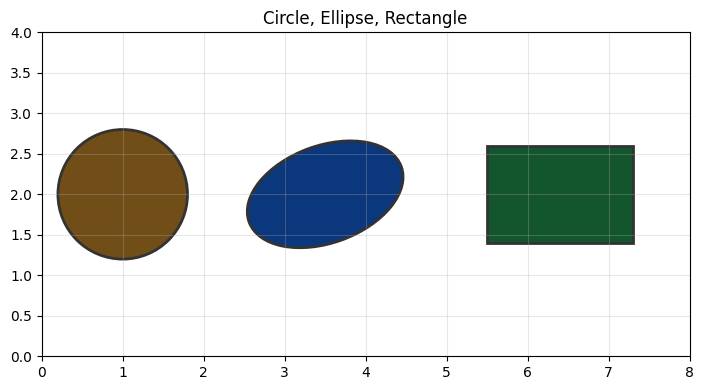

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

# Koło — środek (1, 2), promień 0.8
kolo = mpatches.Circle(
    xy=(1, 2),          # środek
    radius=0.8,
    facecolor="#714E18",
    edgecolor='#333',
    linewidth=2,
)

# Elipsa — środek (3.5, 2), szerokość 2, wysokość 1.2, obrót 20°
elipsa = mpatches.Ellipse(
    xy=(3.5, 2),
    width=2,
    height=1.2,
    angle=20,           # stopnie, przeciwnie do wskazówek zegara
    facecolor="#0B377D",
    edgecolor='#333',
    linewidth=2,
)

# Prostokąt — lewy-dolny róg (5.5, 1.4), szerokość 1.8, wysokość 1.2
prostokat = mpatches.Rectangle(
    xy=(5.5, 1.4),
    width=1.8,
    height=1.2,
    facecolor="#13552D",
    edgecolor='#333',
    linewidth=2,
)

ax.add_patch(kolo)
ax.add_patch(elipsa)
ax.add_patch(prostokat)

# Osie muszą obejmować wszystkie kształty — ustawiamy ręcznie
ax.set_xlim(0, 8)
ax.set_ylim(0, 4)
ax.set_aspect('equal')   # równe skale na X i Y — inaczej koło wygląda jak elipsa!
ax.grid(True, alpha=0.3)
ax.set_title('Circle, Ellipse, Rectangle')
plt.tight_layout()
plt.show()


> **Ważne:** `ax.set_aspect('equal')` — bez tego koło wygląda jak elipsa, bo skale osi X i Y są różne.


### Zadanie 1

Na pustym układzie współrzędnych (xlim 0–10, ylim 0–10) narysuj:
1. Zielone koło o promieniu 1.5 w punkcie (3, 7)
2. Różową elipsę (szerokość 3, wysokość 1.5) obróconą o 45° w punkcie (7, 3)
3. Niebieski prostokąt 2×3 z lewym-dolnym rogiem w (1, 1)

Dla każdego kształtu ustaw `edgecolor='black'`, `linewidth=1.5`.


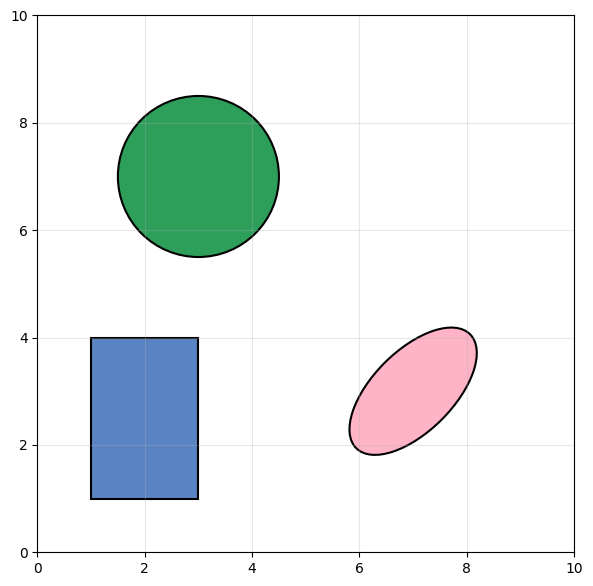

In [3]:
# ROZWIĄZANIE — Zadanie 1

fig, ax = plt.subplots(figsize=(6, 6))

ax.add_patch(mpatches.Circle(xy=(3, 7), radius=1.5,
                              fc='#2E9E5B', ec='black', lw=1.5))

ax.add_patch(mpatches.Ellipse(xy=(7, 3), width=3, height=1.5, angle=45,
                               fc='#FFB3C6', ec='black', lw=1.5))

ax.add_patch(mpatches.Rectangle(xy=(1, 1), width=2, height=3,
                                 fc='#5B84C4', ec='black', lw=1.5))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 2. Jajko wielkanocne

Jajko to elipsa z wzorkiem — paskami lub kółkami.  
Budujemy je warstwami: najpierw tło, potem wzór, potem obrys.

### 2.1 Kształt jajka


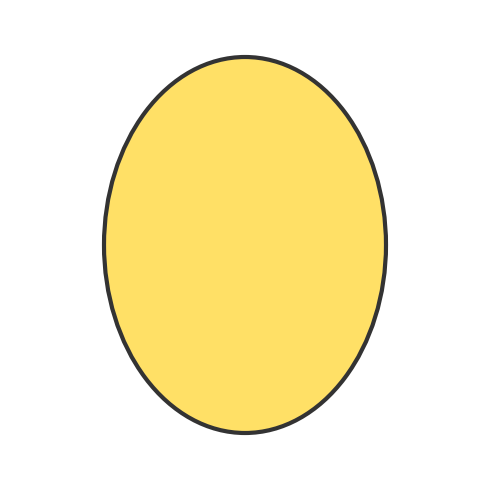

In [4]:
fig, ax = plt.subplots(figsize=(5, 7))

# Jajko = elipsa
jajko = mpatches.Ellipse(
    xy=(0, 0),           # środek w (0, 0) — łatwo obliczać pozycje wzoru
    width=3,
    height=4,
    facecolor='#FFE066',
    edgecolor='#333',
    linewidth=3,
    zorder=1,            # jajko jest spód
)
ax.add_patch(jajko)

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')           # wyłącz osie — rysujemy obrazek, nie wykres
plt.tight_layout()
plt.show()


### 2.2 Wzór — paski

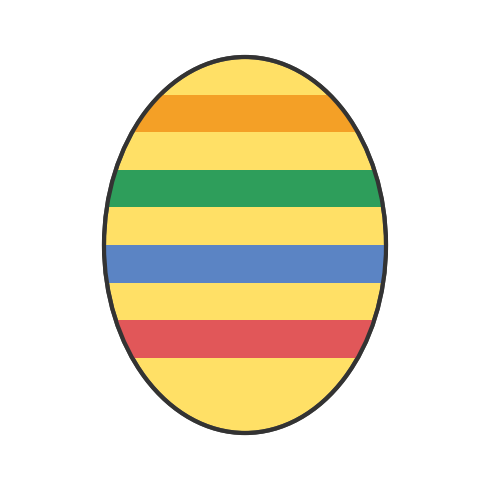

In [5]:
fig, ax = plt.subplots(figsize=(5, 7))

KOLORY_PASKÓW = ['#E15759', '#5B84C4', '#2E9E5B', '#F4A026']

# Jajko — tło
jajko = mpatches.Ellipse(xy=(0, 0), width=3, height=4,
                          fc='#FFE066', ec='#555', lw=3, zorder=1)
ax.add_patch(jajko)

# Paski — każdy przycinany do kształtu jajka przez clip_path
wysokosci = [-1.2, -0.4, 0.4, 1.2]

for i, y in enumerate(wysokosci):
    pasek = mpatches.Rectangle(
        xy=(-1.8, y),
        width=3.6,
        height=0.4,
        facecolor=KOLORY_PASKÓW[i % len(KOLORY_PASKÓW)],
        edgecolor='none',
        zorder=2,
    )
    ax.add_patch(pasek)
    pasek.set_clip_path(jajko)   # ← kluczowa linia

# Obrys na wierzchu
ax.add_patch(mpatches.Ellipse(xy=(0, 0), width=3, height=4,
                               fc='none', ec='#333', lw=3, zorder=3))

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

> **Kluczowy trick z `zorder`:**  
> Tło jajka (zorder=1) → paski (zorder=2) → obrys jajka (zorder=3).  
> Obrys na wierzchu zakrywa „wystające" krawędzie pasków.


### Zadanie 2

Zmodyfikuj jajko żeby miało wzór z **kółek** zamiast pasków.  
Narysuj siatkę ~12 małych kół `Circle` rozłożonych na powierzchni jajka.

*Wskazówka:* pętle `for y in [...]: for x in [...]:` + `Circle(xy=(x, y), radius=0.25)`.  
Kółka poza elipsą będą niewidoczne — zakryje je obrys (zorder=3). To nasza „magia" z zorder.


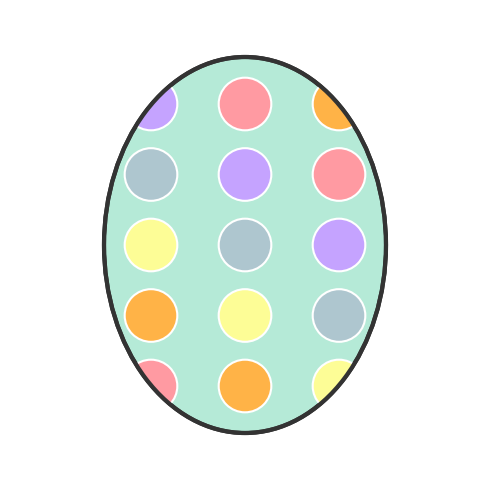

In [6]:
# ROZWIĄZANIE — Zadanie 2

fig, ax = plt.subplots(figsize=(5, 7))

# Tło jajka
jajko = ax.add_patch(mpatches.Ellipse(xy=(0, 0), width=3, height=4,
                               fc='#B5EAD7', ec='#333', lw=3, zorder=1))

# Siatka kółek
kolory_kolek = ['#FF9AA2', '#FFB347', '#FDFD96', '#AEC6CF', '#C5A3FF']
ys = [-1.5, -0.75, 0, 0.75, 1.5]
xs = [-1.0, 0, 1.0]

for i, y in enumerate(ys):
    for j, x in enumerate(xs):
        kol = mpatches.Circle(
            xy=(x, y),
            radius=0.28,
            fc=kolory_kolek[(i + j) % len(kolory_kolek)],
            ec='white',
            lw=1.5,
            zorder=2,
        )
        ax.add_patch(kol)
        kol.set_clip_path(jajko)

# Obrys na wierzchu
ax.add_patch(mpatches.Ellipse(xy=(0, 0), width=3, height=4,
                               fc='none', ec='#333', lw=3, zorder=3))

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


---
## 3. Królik z kształtów

Teraz budujemy królika. To projekt architektoniczny — najpierw planujemy współrzędne, potem kodujemy.

### 3.1 Plan budowy

```
       ( )  ( )    ← uszy: dwie elipsy (pionowe)
      (     )      ← głowa: koło
       o   o       ← oczy: dwa małe kółka
         ω         ← nos: elipsa
      (       )    ← tułów: elipsa (szersza)
       /     \     ← łapy przednie: dwa małe koła
```

Wszystkie kształty rysujemy we współrzędnych — środek królika w (0, 0).


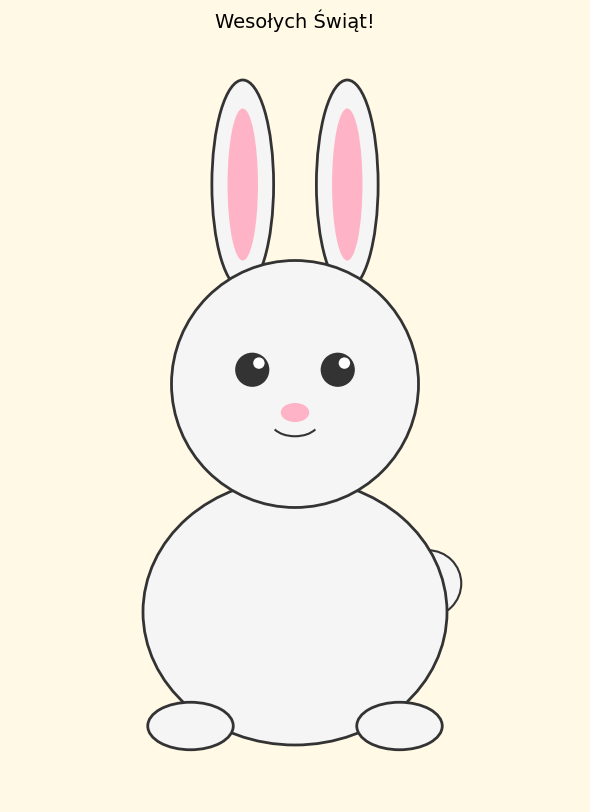

In [7]:
fig, ax = plt.subplots(figsize=(6, 9))

BIEL    = '#F5F5F5'
ROZOWY  = '#FFB3C6'
CIEMNY  = '#333333'

# ── TUŁÓW ────────────────────────────────────────────────────────────
ax.add_patch(mpatches.Ellipse(
    xy=(0, -1.5), width=3.2, height=2.8,
    fc=BIEL, ec=CIEMNY, lw=2, zorder=2))

# ── GŁOWA ────────────────────────────────────────────────────────────
ax.add_patch(mpatches.Circle(
    xy=(0, 0.9), radius=1.3,
    fc=BIEL, ec=CIEMNY, lw=2, zorder=2))

# ── USZY ─────────────────────────────────────────────────────────────
for x_ucho in [-0.55, 0.55]:
    # Zewnętrzne ucho (białe)
    ax.add_patch(mpatches.Ellipse(
        xy=(x_ucho, 3.0), width=0.65, height=2.2,
        fc=BIEL, ec=CIEMNY, lw=2, zorder=1))
    # Wewnętrzne ucho (różowe)
    ax.add_patch(mpatches.Ellipse(
        xy=(x_ucho, 3.0), width=0.32, height=1.6,
        fc=ROZOWY, ec='none', zorder=1))

# ── OCZY ─────────────────────────────────────────────────────────────
for x_oko in [-0.45, 0.45]:
    ax.add_patch(mpatches.Circle(
        xy=(x_oko, 1.05), radius=0.18,
        fc=CIEMNY, ec='none', zorder=3))
    # Odbłysk (mały biały punkcik)
    ax.add_patch(mpatches.Circle(
        xy=(x_oko + 0.07, 1.12), radius=0.06,
        fc='white', ec='none', zorder=4))

# ── NOS ──────────────────────────────────────────────────────────────
ax.add_patch(mpatches.Ellipse(
    xy=(0, 0.6), width=0.3, height=0.2,
    fc=ROZOWY, ec='none', zorder=3))

# ── BUZIA (łuk) ──────────────────────────────────────────────────────
# Arc rysuje tylko obrys (nie wypełnia)
ax.add_patch(mpatches.Arc(
    xy=(0, 0.5), width=0.5, height=0.3,
    angle=0,
    theta1=200, theta2=340,    # kąt startowy i końcowy (stopnie)
    color=CIEMNY, lw=1.5, zorder=3))

# ── ŁAPY ─────────────────────────────────────────────────────────────
for x_lapa in [-1.1, 1.1]:
    ax.add_patch(mpatches.Ellipse(
        xy=(x_lapa, -2.7), width=0.9, height=0.5,
        fc=BIEL, ec=CIEMNY, lw=2, zorder=2))

# ── OGON ─────────────────────────────────────────────────────────────
ax.add_patch(mpatches.Circle(
    xy=(1.4, -1.2), radius=0.35,
    fc=BIEL, ec=CIEMNY, lw=1.5, zorder=1))

ax.set_xlim(-3, 3)
ax.set_ylim(-3.5, 4.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor('#FFF9E6')
fig.patch.set_facecolor('#FFF9E6')
plt.title('Wesołych Świąt!', fontsize=14, pad=10)
plt.tight_layout()
plt.show()


### Zadanie 3 — personalizacja

Zmodyfikuj królika (lub stwórz swojego) — wybierz jedno lub więcej:

**Poziom łatwy:**
- Zmień kolory (`fc=`) — np. szary królik (`'#CCCCCC'`), lub pastelowy
- Dodaj trawę pod królikiem: poziome `Rectangle` w odcieniach zieleni

**Poziom średni:**
- Dodaj kolorowe jajko obok królika (przepisz z Sekcji 2!)
- Narysuj drugie oko z `Polygon` zamiast `Circle` — trójkąt jako „mrugające oko"

**Poziom trudny:**
- Dodaj chmurki — kilka nachodzących na siebie `Circle` o różnych promieniach
- Użyj `plt.text()` żeby dodać wielkanocne życzenia z niestandardową czcionką

*Wskazówka do `plt.text()`:*  
```python
ax.text(0, -3.2, 'Wesołych Świąt!', ha='center', fontsize=13,
        color='#E15759', fontstyle='italic')
```


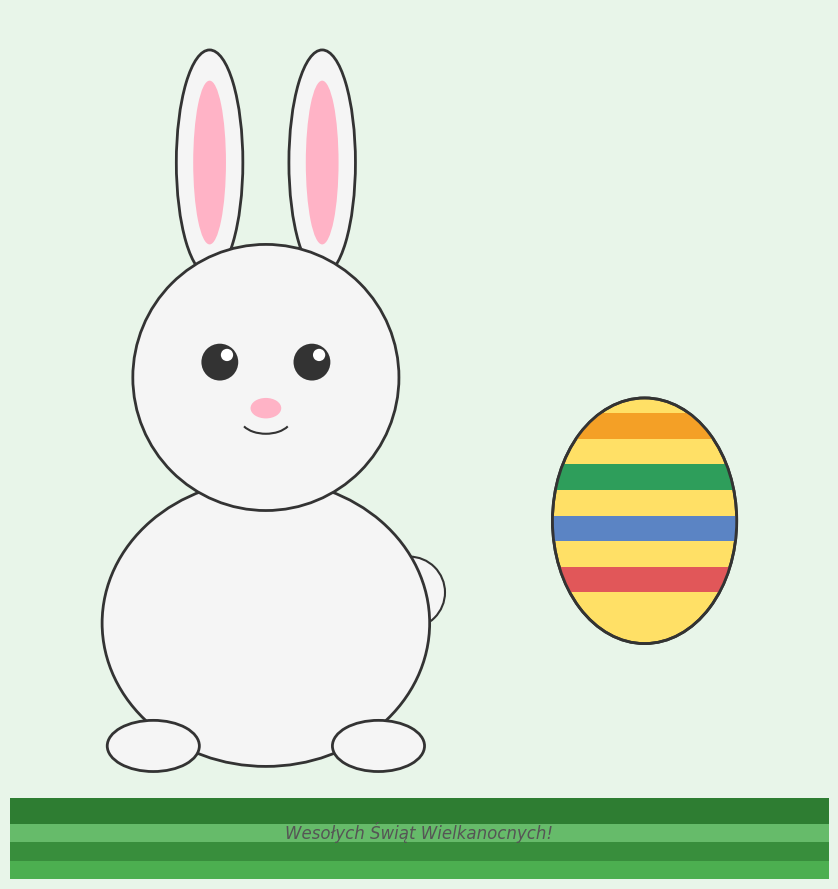

In [8]:
# ROZWIĄZANIE — Zadanie 3 (przykład: królik z jajkiem i trawą)

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_facecolor('#E8F5E9')
fig.patch.set_facecolor('#E8F5E9')

BIEL   = '#F5F5F5'
ROZOWY = '#FFB3C6'
CIEMNY = '#333333'

# --- TRAWA ---
trawa_kolory = ['#4CAF50', '#388E3C', '#66BB6A', '#2E7D32']
for i, kolor in enumerate(trawa_kolory):
    ax.add_patch(mpatches.Rectangle(
        xy=(-4.5, -4.0 + i * 0.18), width=9, height=0.25,
        fc=kolor, ec='none', zorder=1))

# --- KRÓLIK (przesunięty w lewo) ---
ox = -1.5   # offset X

def add_rabbit(ax, ox=0, oy=0):
    ax.add_patch(mpatches.Ellipse(xy=(ox, oy-1.5), width=3.2, height=2.8,
                                   fc=BIEL, ec=CIEMNY, lw=2, zorder=2))
    ax.add_patch(mpatches.Circle(xy=(ox, oy+0.9), radius=1.3,
                                  fc=BIEL, ec=CIEMNY, lw=2, zorder=2))
    for x_ucho in [-0.55, 0.55]:
        ax.add_patch(mpatches.Ellipse(xy=(ox+x_ucho, oy+3.0), width=0.65, height=2.2,
                                       fc=BIEL, ec=CIEMNY, lw=2, zorder=1))
        ax.add_patch(mpatches.Ellipse(xy=(ox+x_ucho, oy+3.0), width=0.32, height=1.6,
                                       fc=ROZOWY, ec='none', zorder=1))
    for x_oko in [-0.45, 0.45]:
        ax.add_patch(mpatches.Circle(xy=(ox+x_oko, oy+1.05), radius=0.18,
                                      fc=CIEMNY, ec='none', zorder=3))
        ax.add_patch(mpatches.Circle(xy=(ox+x_oko+0.07, oy+1.12), radius=0.06,
                                      fc='white', ec='none', zorder=4))
    ax.add_patch(mpatches.Ellipse(xy=(ox, oy+0.6), width=0.3, height=0.2,
                                   fc=ROZOWY, ec='none', zorder=3))
    ax.add_patch(mpatches.Arc(xy=(ox, oy+0.5), width=0.5, height=0.3,
                               angle=0, theta1=200, theta2=340,
                               color=CIEMNY, lw=1.5, zorder=3))
    for x_lapa in [-1.1, 1.1]:
        ax.add_patch(mpatches.Ellipse(xy=(ox+x_lapa, oy-2.7), width=0.9, height=0.5,
                                       fc=BIEL, ec=CIEMNY, lw=2, zorder=2))
    ax.add_patch(mpatches.Circle(xy=(ox+1.4, oy-1.2), radius=0.35,
                                  fc=BIEL, ec=CIEMNY, lw=1.5, zorder=1))

add_rabbit(ax, ox=-1.5)

# --- JAJKO (po prawej) ---
def add_egg(ax, cx, cy, colors):
    jajko = mpatches.Ellipse(xy=(cx, cy), width=1.8, height=2.4,
                              fc='#FFE066', ec='#333', lw=2, zorder=2)
    ax.add_patch(jajko)

    for i, y in enumerate([-0.7, -0.2, 0.3, 0.8]):
        pasek = mpatches.Rectangle(xy=(cx-1.1, cy+y), width=2.2, height=0.25,
                                    fc=colors[i % len(colors)], ec='none', zorder=3)
        ax.add_patch(pasek)
        pasek.set_clip_path(jajko)

    ax.add_patch(mpatches.Ellipse(xy=(cx, cy), width=1.8, height=2.4,
                                   fc='none', ec='#333', lw=2, zorder=4))

add_egg(ax, cx=2.2, cy=-0.5,
        colors=['#E15759', '#5B84C4', '#2E9E5B', '#F4A026'])

# --- NAPIS ---
ax.text(0, -3.6, 'Wesołych Świąt Wielkanocnych!',
        ha='center', fontsize=12, color='#555', fontstyle='italic')

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4.5)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


---
## Podsumowanie

### Nowe narzędzia

| Klasa / funkcja | Do czego |
|---|---|
| `mpatches.Circle` | koło |
| `mpatches.Ellipse` | elipsa, obrót kątem `angle=` |
| `mpatches.Rectangle` | prostokąt |
| `mpatches.Polygon` | dowolny wielokąt z listy wierzchołków |
| `mpatches.Arc` | łuk — tylko obrys, bez wypełnienia |
| `ax.add_patch(p)` | dodaje patch do wykresu |
| `ax.set_aspect('equal')` | równe skale osi — koło to koło |
| `ax.axis('off')` | wyłącza osie (obrazek bez osi) |
| `zorder=` | kolejność rysowania — wyższy = na wierzchu |
| `ax.text(x, y, ...)` | tekst w dowolnym miejscu |

### Powiązanie z wykresami

Patche są używane przez matplotlib **wewnętrznie** do rysowania wszystkich wykresów:
- słupek histogramu = `Rectangle`
- marker scatter plot = `Circle` lub inny kształt
- pudełko boxplotu = `Rectangle` + `FancyArrow`

Teraz wiesz skąd pochodzą kształty na Twoich wykresach.
